In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from collections import Counter

# Import data and split into labeled, unlabeled and test

In [22]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# -------- 1. Paths --------
BASE_DIR = "Reduced MNIST Data"
TRAIN_DIR = os.path.join(BASE_DIR, "Reduced Training data")
TEST_DIR = os.path.join(BASE_DIR, "Reduced Testing data")


# -------- 2. Load images from folder structure --------
def load_mnist_from_folders(root_dir):
    X = []
    y = []

    for label_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, label_name)

        if not os.path.isdir(class_dir):
            continue

        label = int(label_name)

        for filename in sorted(os.listdir(class_dir)):
            file_path = os.path.join(class_dir, filename)

            if not os.path.isfile(file_path):
                continue

            try:
                img = Image.open(file_path).convert("L")
                img = np.array(img, dtype=np.float32)

                if img.shape != (28, 28):
                    raise ValueError(f"Unexpected image shape {img.shape} in {file_path}")

                img = img / 255.0
                img = img.flatten()   # (28, 28) -> (784,)

                X.append(img)
                y.append(label)

            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y

# -------- 3. Load full training and testing data --------
X_train_full, y_train_full = load_mnist_from_folders(TRAIN_DIR)
X_test, y_test = load_mnist_from_folders(TEST_DIR)

print("Full training set:", X_train_full.shape, y_train_full.shape)
print("Test set:", X_test.shape, y_test.shape)



Full training set: (10000, 784) (10000,)
Test set: (2000, 784) (2000,)


# The Three Uncertainty Function (Least confidence, margin, entropy)

In [23]:
def compute_uncertainty(probs, method="least_confidence"):
    """
    probs: shape (n_samples, n_classes)
    returns: uncertainty scores of shape (n_samples,)
    Higher score = more uncertain
    """
    if method == "least_confidence":
        return 1 - np.max(probs, axis=1)

    elif method == "entropy":
        eps = 1e-12
        return -np.sum(probs * np.log(probs + eps), axis=1)

    elif method == "margin":
        sorted_probs = np.sort(probs, axis=1)
        top1 = sorted_probs[:, -1]
        top2 = sorted_probs[:, -2]
        margin = top1 - top2
        return -margin

    else:
        raise ValueError(f"Unknown method: {method}")

# Active Learning Function

In [24]:
def run_active_learning(
    X_labeled_init,
    y_labeled_init,
    X_unlabeled_init,
    y_unlabeled_init,
    X_test,
    y_test,
    strategy="random",
    num_rounds=50,
    random_state=SEED
):
    X_labeled = X_labeled_init.copy()
    y_labeled = y_labeled_init.copy()
    X_unlabeled = X_unlabeled_init.copy()
    y_unlabeled = y_unlabeled_init.copy()

    rng = np.random.default_rng(random_state)

    accuracies = []
    labeled_sizes = []

    for step in range(num_rounds):
        model = LogisticRegression(max_iter=1000, C=1.0)
        model.fit(X_labeled, y_labeled)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        accuracies.append(acc)
        labeled_sizes.append(len(X_labeled))
        
        print(f"[{strategy}] Step {step}: labeled={len(X_labeled)}, acc={acc:.4f}")

        if len(X_unlabeled) == 0:
            break

        if strategy == "random":
            query_index = rng.integers(len(X_unlabeled))

        else:
            probs = model.predict_proba(X_unlabeled)
            uncertainty = compute_uncertainty(probs, method=strategy)
            query_index = np.argmax(uncertainty)

        X_query = X_unlabeled[query_index:query_index+1]
        y_query = y_unlabeled[query_index:query_index+1]

        X_labeled = np.concatenate([X_labeled, X_query], axis=0)
        y_labeled = np.concatenate([y_labeled, y_query], axis=0)

        X_unlabeled = np.delete(X_unlabeled, query_index, axis=0)
        y_unlabeled = np.delete(y_unlabeled, query_index, axis=0)

    return labeled_sizes, accuracies

# Køre de 3 uncertainty samplings og random sampling

In [25]:
from sklearn.model_selection import train_test_split
import numpy as np

initial_label_sizes = [50, 100, 200, 500]
strategies = ["random", "least_confidence", "entropy", "margin"]
seeds = [0,1,2,3,4,5,6,7,8,9]

all_results = {}

for n_initial_labeled in initial_label_sizes:
    seed_results = {strategy: [] for strategy in strategies}

    for seed in seeds:
        X_labeled_init, X_unlabeled_init, y_labeled_init, y_unlabeled_init = train_test_split(
            X_train_full,
            y_train_full,
            train_size=n_initial_labeled,
            stratify=y_train_full,
            random_state=seed
        )

        for strategy in strategies:
            labeled_sizes, accuracies = run_active_learning(
                X_labeled_init,
                y_labeled_init,
                X_unlabeled_init,
                y_unlabeled_init,
                X_test,
                y_test,
                strategy=strategy,
                num_rounds=50,
                random_state=seed
            )

            best_accuracies = np.maximum.accumulate(accuracies)
            seed_results[strategy].append(best_accuracies)

    all_results[n_initial_labeled] = seed_results

[random] Step 0: labeled=50, acc=0.7920
[random] Step 1: labeled=51, acc=0.7945
[random] Step 2: labeled=52, acc=0.7965
[random] Step 3: labeled=53, acc=0.7950
[random] Step 4: labeled=54, acc=0.7960
[random] Step 5: labeled=55, acc=0.7965
[random] Step 6: labeled=56, acc=0.8010
[random] Step 7: labeled=57, acc=0.7995
[random] Step 8: labeled=58, acc=0.7990
[random] Step 9: labeled=59, acc=0.7975
[random] Step 10: labeled=60, acc=0.7975
[random] Step 11: labeled=61, acc=0.8005
[random] Step 12: labeled=62, acc=0.8010
[random] Step 13: labeled=63, acc=0.7985
[random] Step 14: labeled=64, acc=0.7990
[random] Step 15: labeled=65, acc=0.7980
[random] Step 16: labeled=66, acc=0.7970
[random] Step 17: labeled=67, acc=0.7950
[random] Step 18: labeled=68, acc=0.8025
[random] Step 19: labeled=69, acc=0.8035
[random] Step 20: labeled=70, acc=0.8025
[random] Step 21: labeled=71, acc=0.8010
[random] Step 22: labeled=72, acc=0.7975
[random] Step 23: labeled=73, acc=0.7995
[random] Step 24: labeled=

# Plot performance

Shared y-axis: 0.7550500000000001 0.90455

Initial labeled set = 50
random: final accuracy = 0.8084 ± 0.0199
least_confidence: final accuracy = 0.8145 ± 0.0117
entropy: final accuracy = 0.8126 ± 0.0100
margin: final accuracy = 0.8407 ± 0.0075

Initial labeled set = 100
random: final accuracy = 0.8397 ± 0.0095
least_confidence: final accuracy = 0.8543 ± 0.0078
entropy: final accuracy = 0.8505 ± 0.0099
margin: final accuracy = 0.8557 ± 0.0102

Initial labeled set = 200
random: final accuracy = 0.8680 ± 0.0059
least_confidence: final accuracy = 0.8764 ± 0.0062
entropy: final accuracy = 0.8790 ± 0.0077
margin: final accuracy = 0.8802 ± 0.0050

Initial labeled set = 500
random: final accuracy = 0.8886 ± 0.0029
least_confidence: final accuracy = 0.8933 ± 0.0038
entropy: final accuracy = 0.8944 ± 0.0037
margin: final accuracy = 0.8945 ± 0.0026


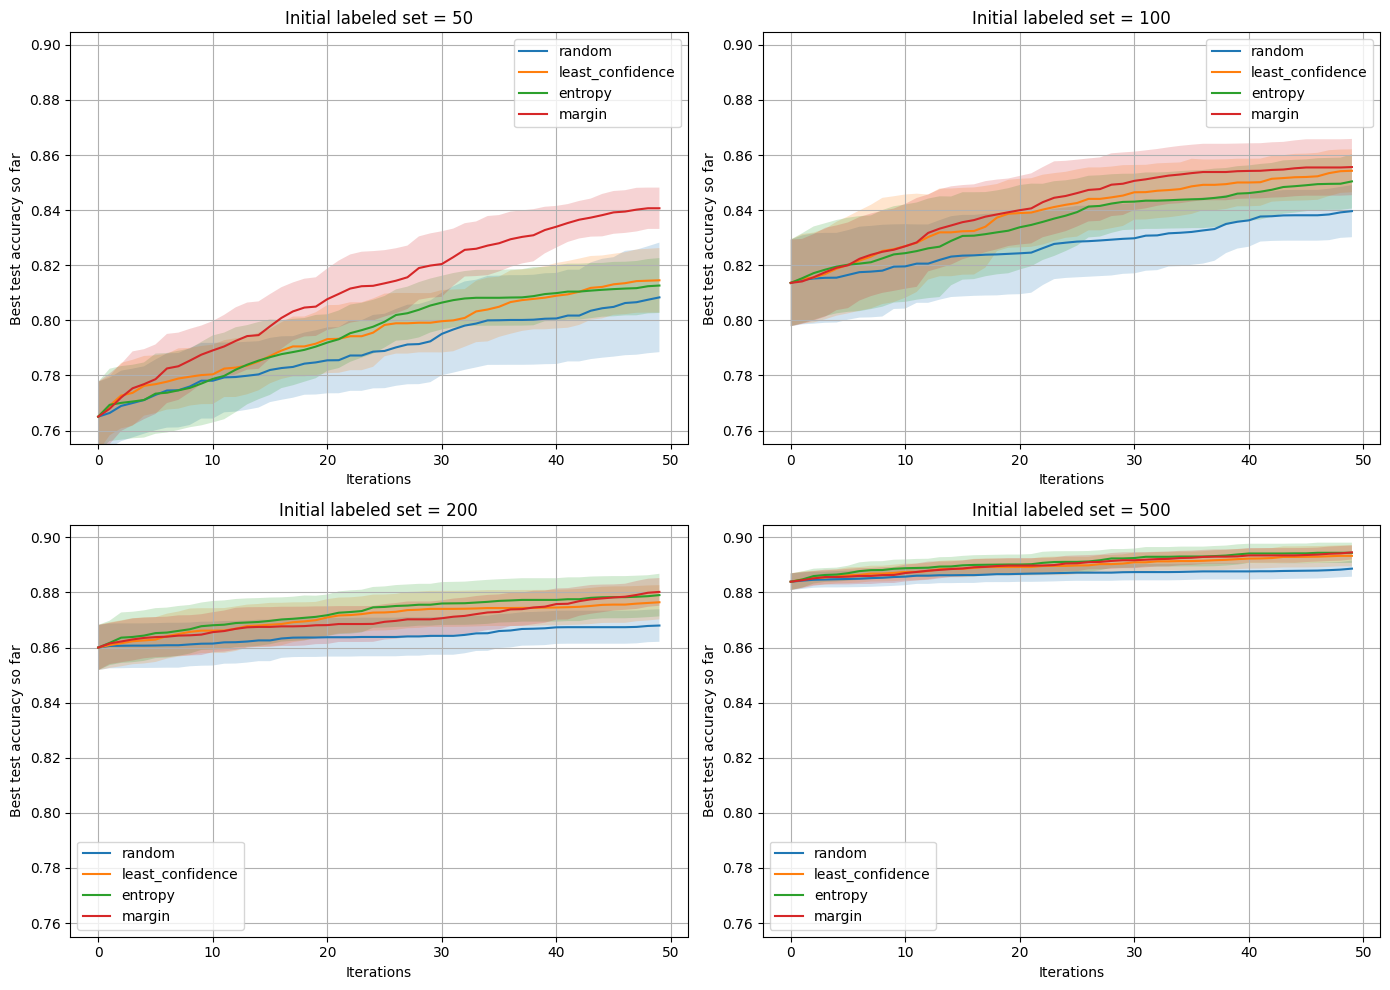

In [27]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_means = []

# Først: beregn alle means for at finde fælles y-akse
for n_initial_labeled in initial_label_sizes:
    for strategy in strategies:
        data = np.array(all_results[n_initial_labeled][strategy])
        mean = data.mean(axis=0)
        all_means.extend(mean)

y_min = max(0, min(all_means) - 0.01)
y_max = min(1, max(all_means) + 0.01)

print("Shared y-axis:", y_min, y_max)

# Plot
for ax, n_initial_labeled in zip(axes, initial_label_sizes):

    print(f"\nInitial labeled set = {n_initial_labeled}")

    for strategy in strategies:
        data = np.array(all_results[n_initial_labeled][strategy])

        mean = data.mean(axis=0)
        std = data.std(axis=0)

        # 95% confidence interval
        ci = 1.96 * std / np.sqrt(data.shape[0])

        x = range(len(mean))

        ax.plot(x, mean, label=strategy)
        ax.fill_between(x, mean - ci, mean + ci, alpha=0.2)

        # Print CI for sidste punkt (mest relevant)
        print(f"{strategy}: final accuracy = {mean[-1]:.4f} ± {ci[-1]:.4f}")

    ax.set_title(f"Initial labeled set = {n_initial_labeled}")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Best test accuracy so far")
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()